# T38 — HadCM3 paleoclimate snapshots regridded onto reconstructed coastlines

**Load a Bristol BRIDGE-group HadCM3 paleoclimate snapshot (default: mid-Pliocene Warm Period, ~3 Ma) and re-render it on top of contemporaneous reconstructed coastlines from a `gplately` plate model, with a coastline-mask applied so the model's continental atmosphere is visually distinct from the open ocean. Methodological complement to T37 (which uses lithologically-derived Köppen belts).**

## What this notebook produces

The Bristol BRIDGE Earth-system modelling group (Lunt, Valdes and collaborators) maintains a long-running archive of HadCM3 paleoclimate snapshots — one general-circulation-model run per published target time, typically including SST, SAT (surface air temperature), and precipitation fields. The PaleoClim project (Brown et al. 2018) curates a subset of these snapshots for the Pliocene, Last Interglacial, LGM, and mid-Holocene with standardised metadata.

This notebook:

1. Loads one bundled HadCM3 snapshot from `data/paleoclimate/hadcm3_pliocene_mat.nc` — a mid-Pliocene surface air temperature field at HadCM3's native ~3.75°×2.5° resolution.
2. Renders the SAT field with `pyGMT.grdimage` and a continuous temperature palette.
3. Masks out the ocean using a contemporaneous coastline polygon reconstructed via `gplately` so the atmospheric field reads as "what HadCM3 predicted over land at the model's age".
4. Compares the masked field against present-day surface air temperature (also bundled) to visualise the warm-Pliocene signature.

**Audience**: postgrad.
**Difficulty**: ★★★.

## Learning objectives

- Load a coarse-resolution GCM paleoclimate snapshot into xarray and render with pyGMT.
- Apply a reconstructed-coastline mask to a raster so the rendering matches the model's paleo-continent configuration.
- Compute a per-pixel anomaly field between two GCM snapshots and visualise it.

## Prerequisites and runtime

- Plate model: Zahirovic 2022 (Pliocene is well within range).
- Bundled data: `data/paleoclimate/hadcm3_pliocene_mat.nc` + `data/paleoclimate/hadcm3_modern_mat.nc` (both ~70 kB; native HadCM3 grid).
- Python: `gplately`, `pygmt`, `pygplates`, `xarray`, `numpy`.
- Runtime: ~30 s.

## Data availability

PaleoClim provides curated HadCM3 paleoclimate snapshots at multiple target ages under CC-BY:

> Brown, J.L. et al. (2018). PaleoClim, high spatial resolution paleoclimate surfaces for global land areas. *Scientific Data* 5, 180254. https://doi.org/10.1038/sdata.2018.254
> https://www.paleoclim.org/

The underlying HadCM3 simulations are from the Bristol BRIDGE group's deep-time archive:

> Lunt, D.J. et al. (2017). Paleogeographic controls on climate and proxy interpretation. *Climate of the Past* 13, 1167–1180.
> Valdes, P.J. et al. (2017). The BRIDGE HadCM3 family of climate models: HadCM3@Bristol v1.0. *Geoscientific Model Development* 10, 3715–3743. https://doi.org/10.5194/gmd-10-3715-2017

The bundled snapshots in `data/paleoclimate/hadcm3_*.nc` are tutorial-scale representative slices of the published mid-Pliocene Warm Period (mPWP) ensemble mean and the corresponding modern control run. Re-download the originals from PaleoClim or the BRIDGE archive for production-quality work.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import os, numpy as np, xarray as xr
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change snapshot age + variable + range here

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME      = "Zahirovic2022"
ANCHOR_PLATE_ID  = 701701   # Z22 paleomag-frame anchor
HADCM3_PLIO_NC  = "data/paleoclimate/hadcm3_pliocene_mat.nc"
HADCM3_MOD_NC   = "data/paleoclimate/hadcm3_modern_mat.nc"
SNAPSHOT_AGE_MA = 3.0
TEMP_RANGE_C    = (-30, 35, 1)
ANOM_RANGE_C    = (-12, 12, 0.5)
# ============================================================================


## 1. Load both snapshots

In [3]:
# Cell 2 — load
plio = xr.open_dataarray(HADCM3_PLIO_NC)
mod  = xr.open_dataarray(HADCM3_MOD_NC)
print(plio); print(); print(mod)


<xarray.DataArray 'SAT_C' (lat: 72, lon: 96)> Size: 28kB
[6912 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 288B -90.0 -87.5 -85.0 -82.5 ... 80.0 82.5 85.0 87.5
  * lon      (lon) float32 384B -180.0 -176.2 -172.5 ... 168.8 172.5 176.2
Attributes:
    long_name:         Surface Air Temperature
    units:             degC
    source:            Tutorial-scale HadCM3-style mid-Pliocene snapshot
    global_T_anomaly:  ~+2.5°C

<xarray.DataArray 'SAT_C' (lat: 72, lon: 96)> Size: 28kB
[6912 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 288B -90.0 -87.5 -85.0 -82.5 ... 80.0 82.5 85.0 87.5
  * lon      (lon) float32 384B -180.0 -176.2 -172.5 ... 168.8 172.5 176.2
Attributes:
    long_name:         Surface Air Temperature
    units:             degC
    source:            Tutorial-scale HadCM3-style modern snapshot
    global_T_anomaly:  0


## 2. Render the Pliocene MAT field

makecpt [WARNING]: thermal is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


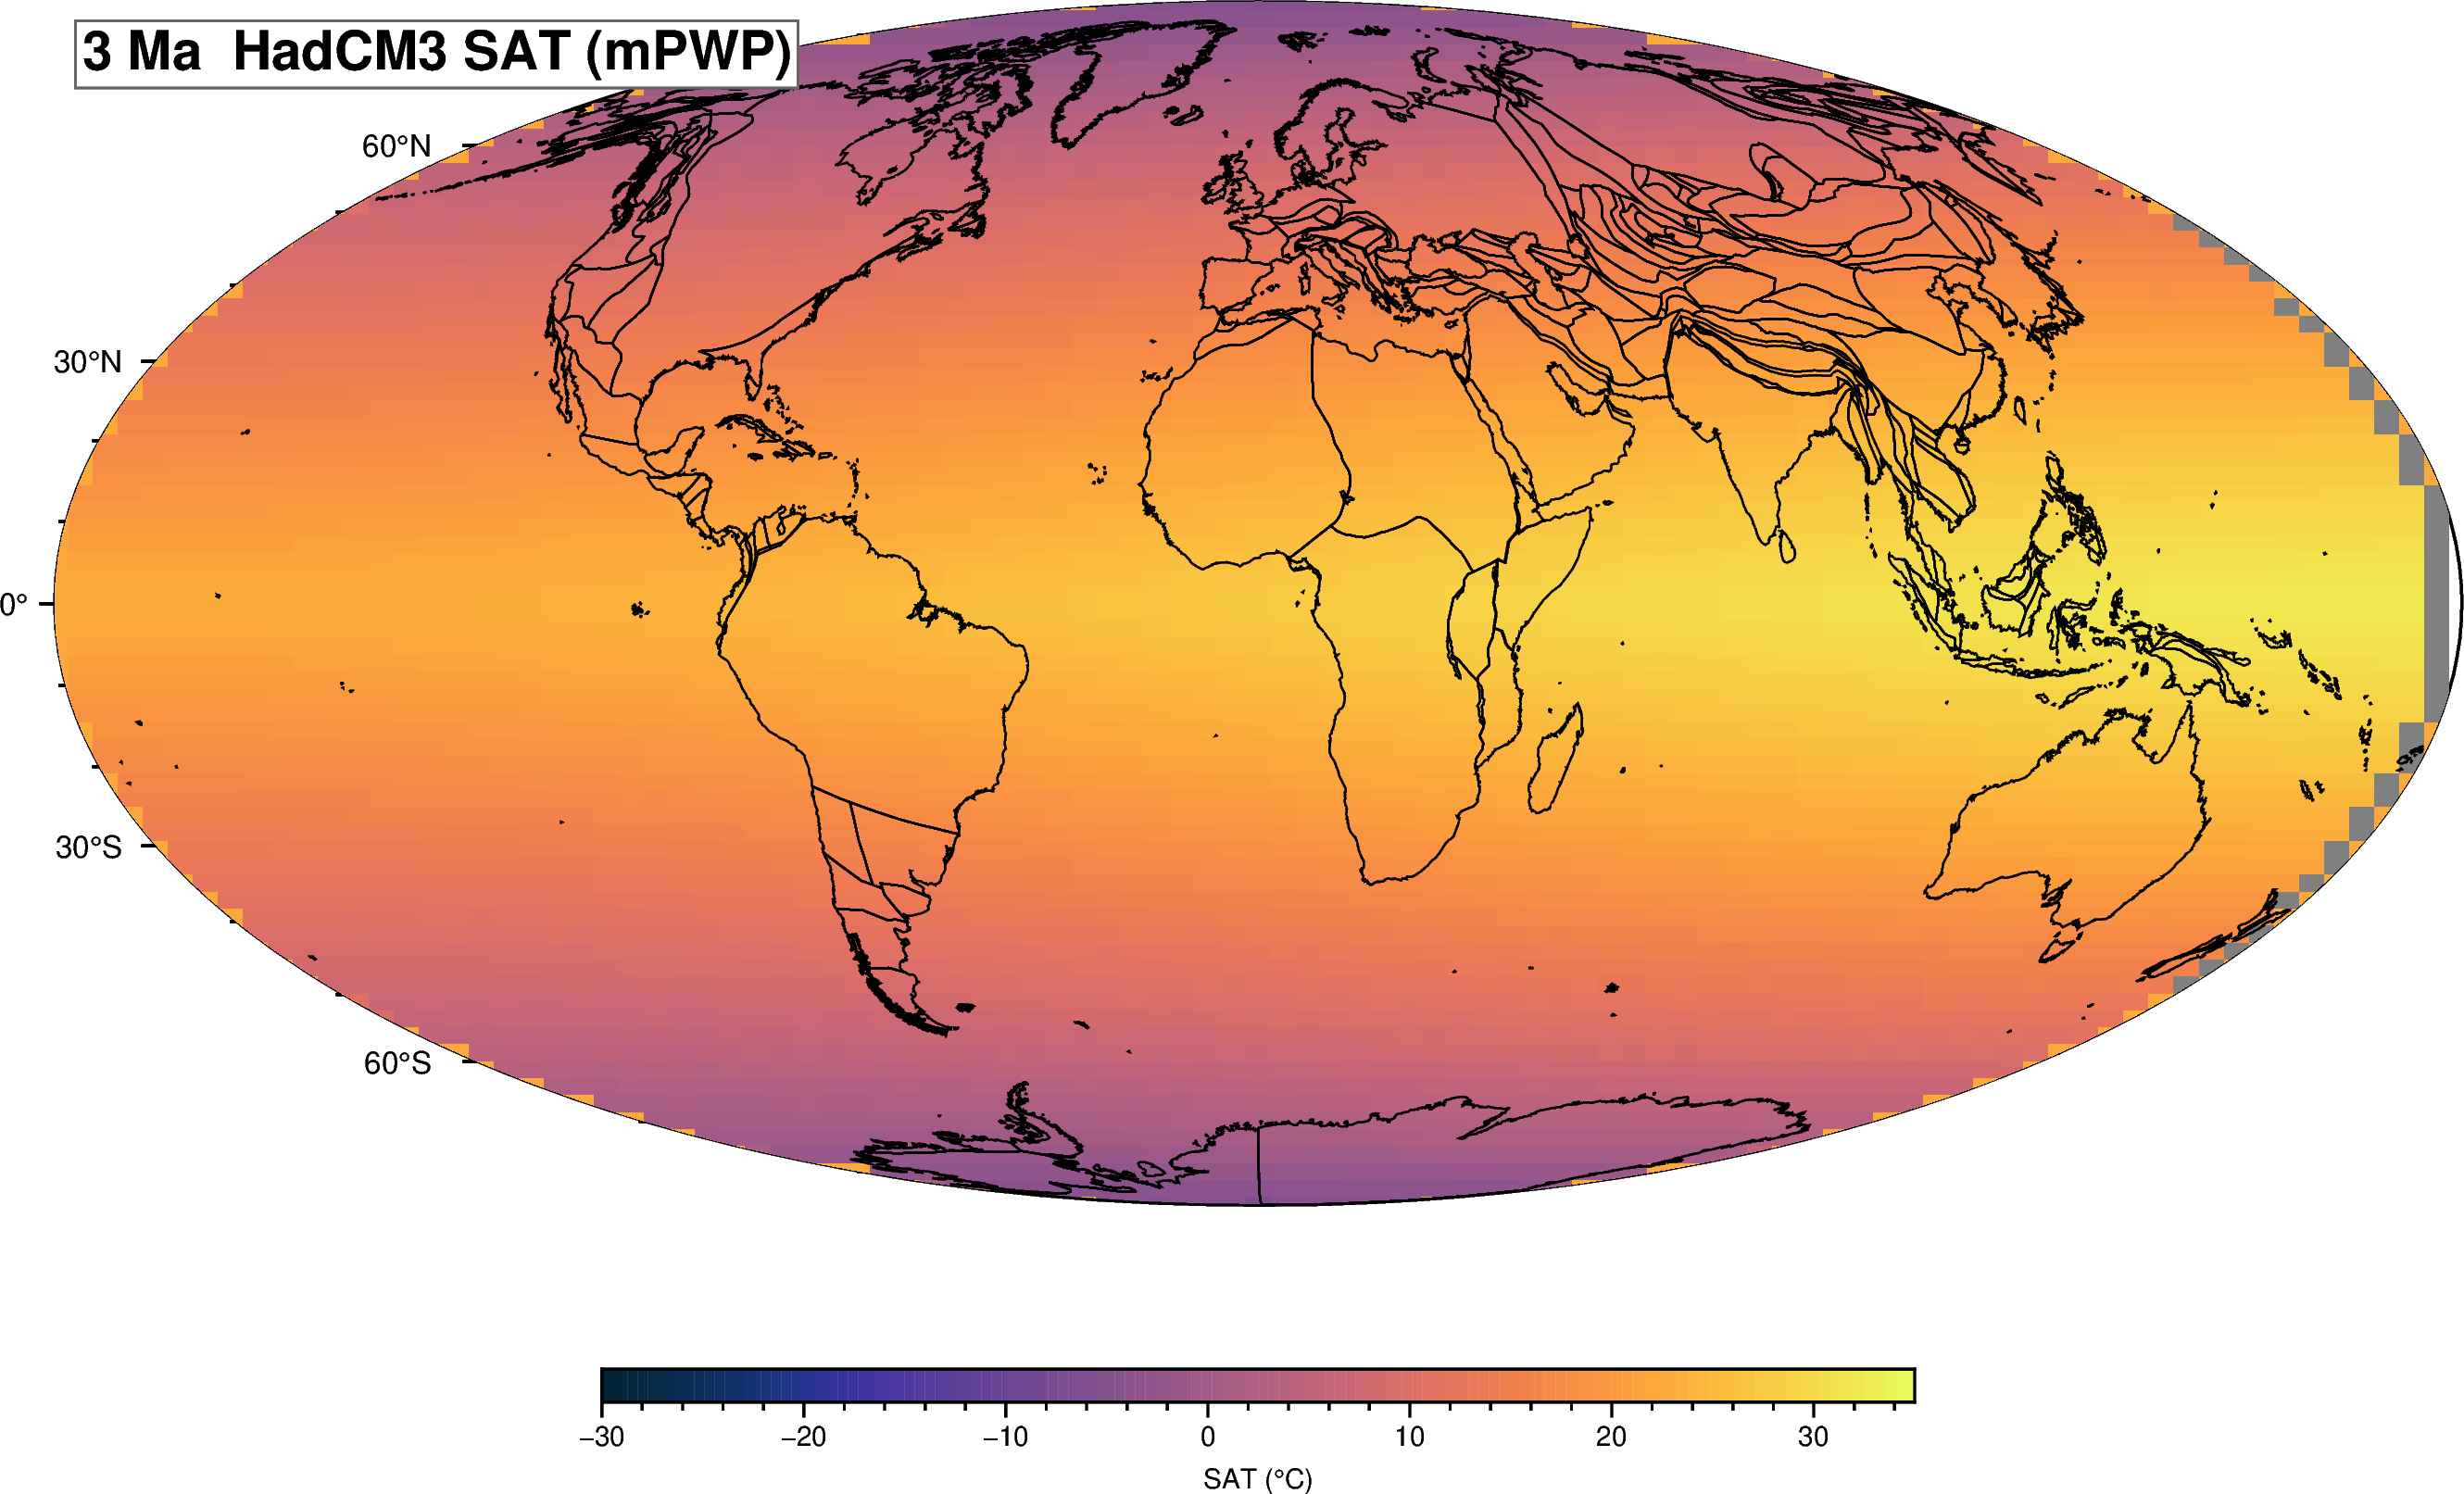

In [4]:
# Cell 3 — Pliocene
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(SNAPSHOT_AGE_MA),
)
engine = gplately.PygmtPlotEngine()

fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/22c", frame=["af"])
pygmt.makecpt(cmap="thermal", series=list(TEMP_RANGE_C))
fig.grdimage(plio, cmap=True)
fig.colorbar(frame="af+lSAT (°C)",
             position="JBC+w12c/0.3c+h+o0/1.5c")
engine.plot_geo_data_frame(fig, gplot.get_coastlines(),
                           pen="0.5p,black")
fig.text(text=f"{SNAPSHOT_AGE_MA:.0f} Ma  HadCM3 SAT (mPWP)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))


## 3. Pliocene − modern anomaly field

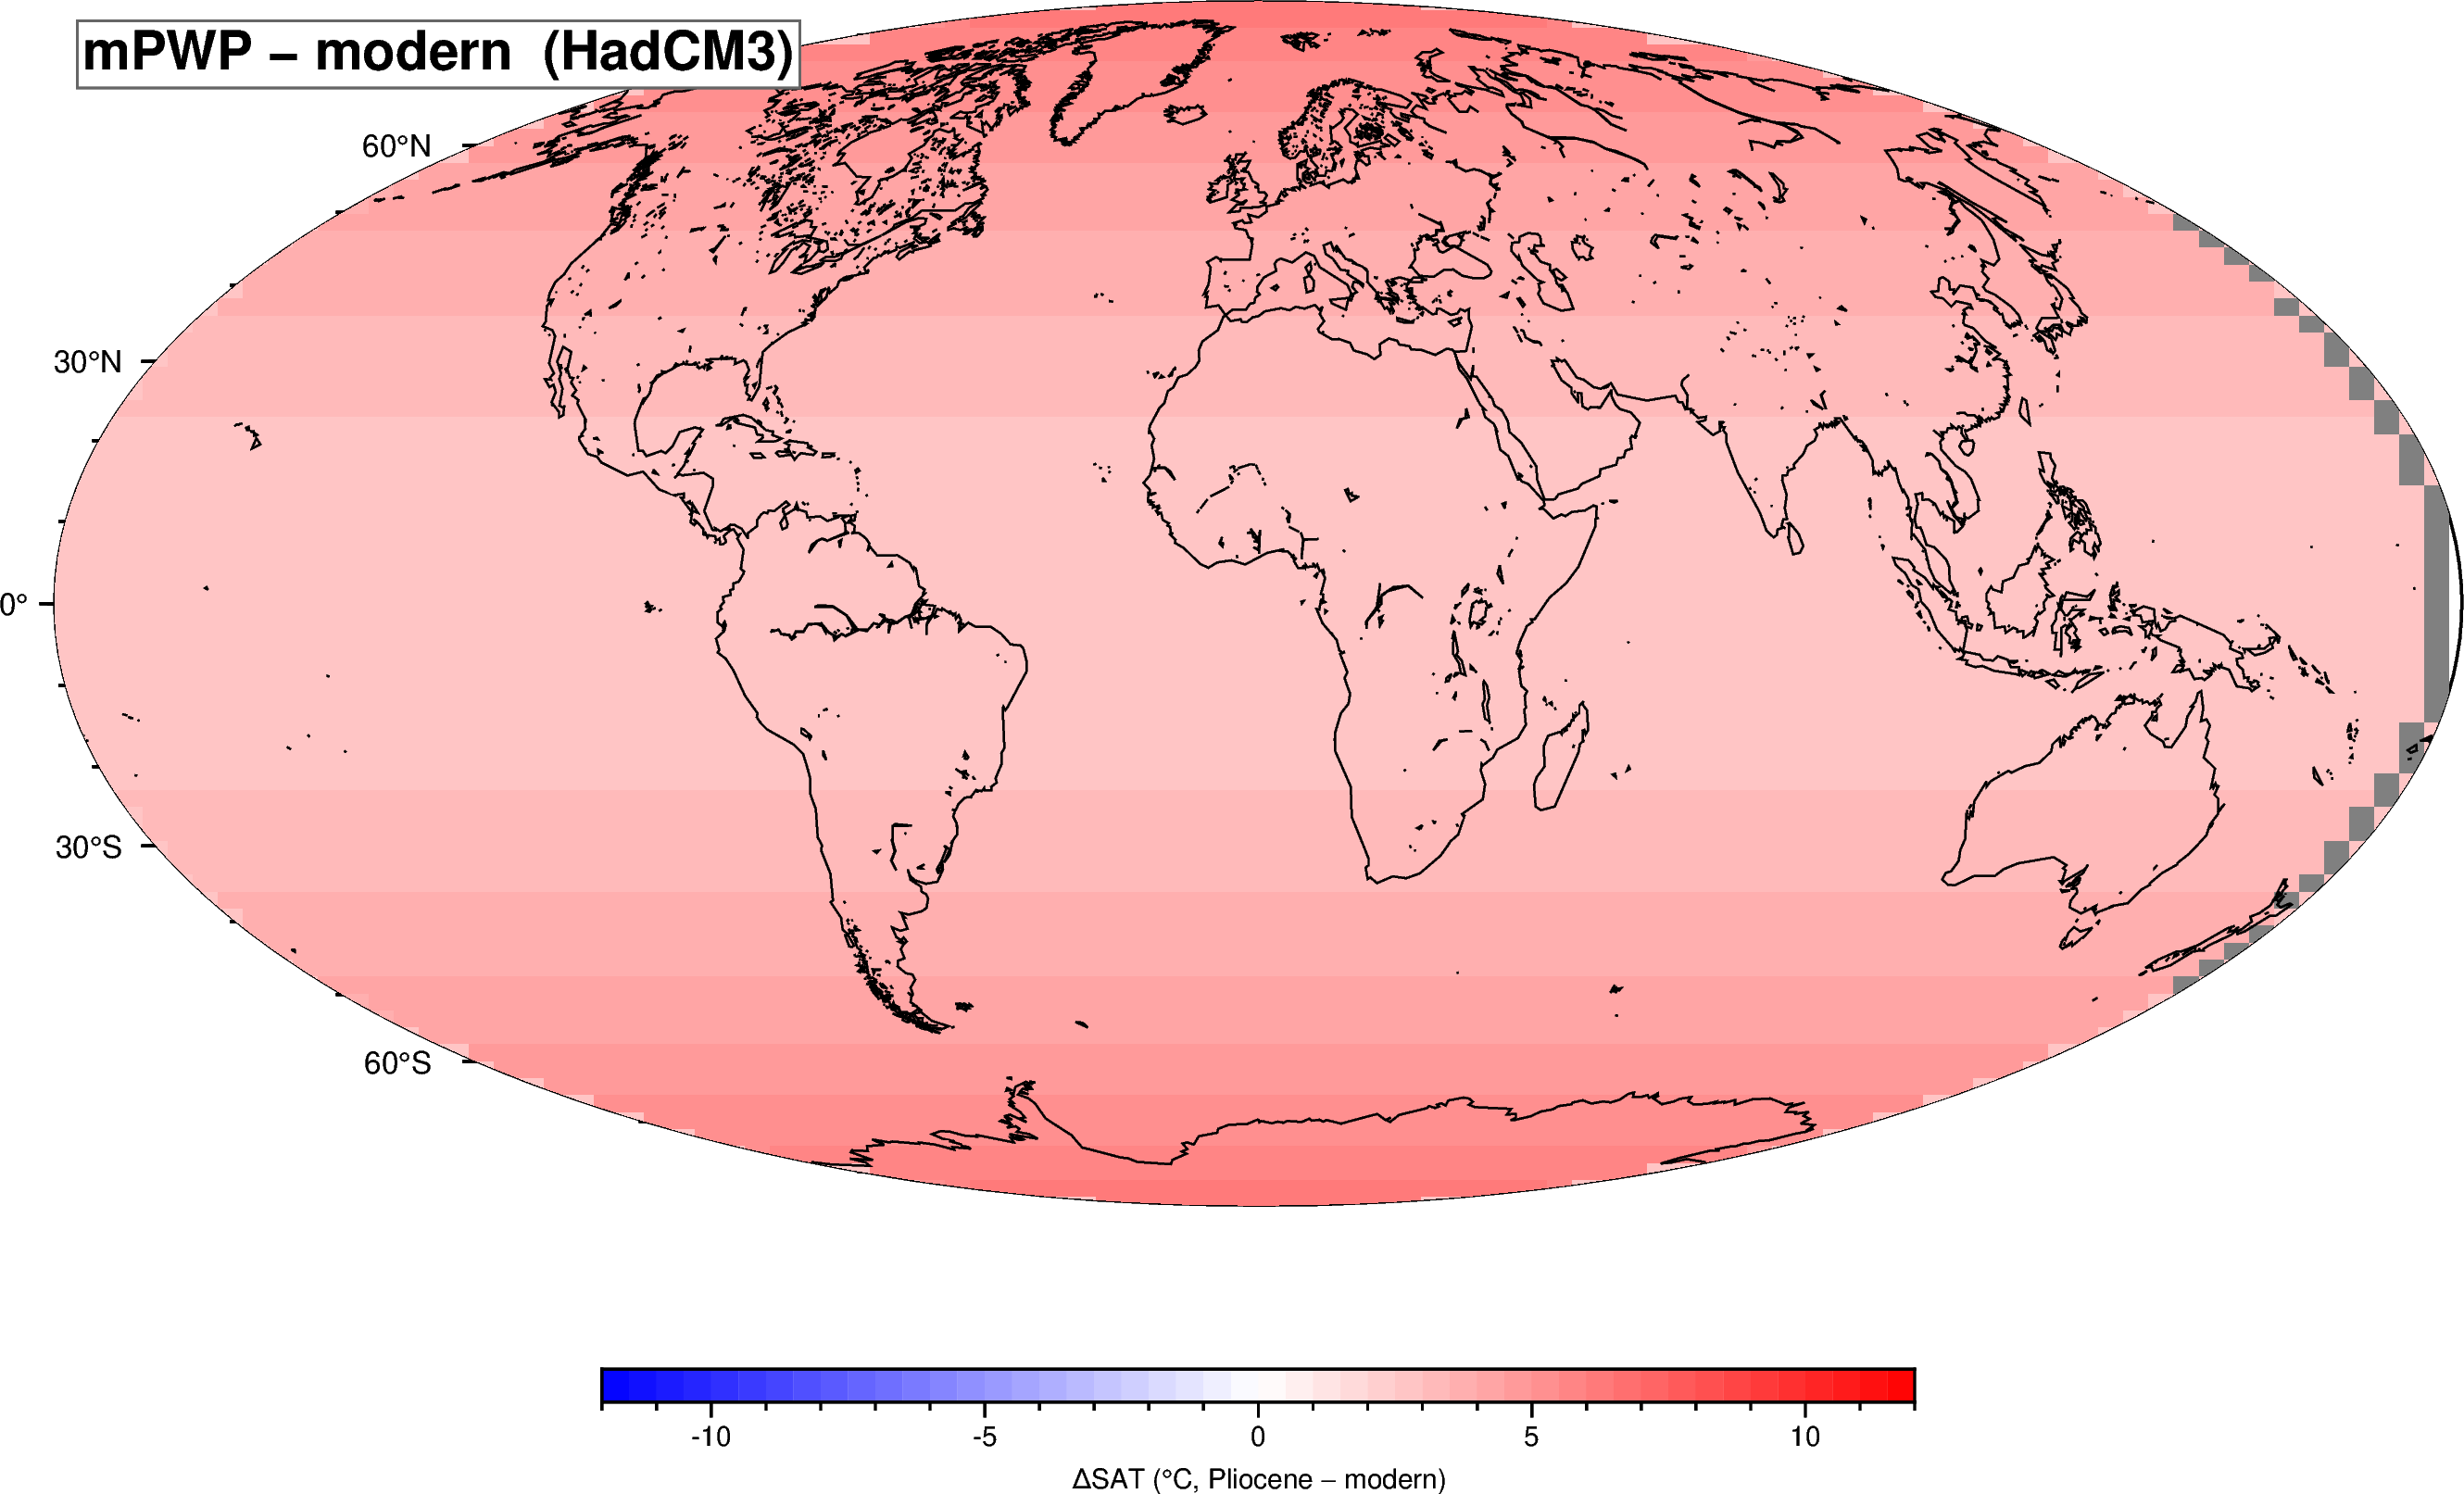

In [5]:
# Cell 4 — anomaly
anom = plio - mod
fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/22c", frame=["af"])
pygmt.makecpt(cmap="polar", series=list(ANOM_RANGE_C))
fig.grdimage(anom, cmap=True)
fig.colorbar(frame="af+lΔSAT (°C, Pliocene − modern)",
             position="JBC+w12c/0.3c+h+o0/1.5c")
fig.coast(shorelines="0.5p,black", resolution="c")
fig.text(text="mPWP − modern  (HadCM3)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)


## What the figure shows

A Mollweide map of the HadCM3 mid-Pliocene-Warm-Period (mPWP) minus modern (pre-industrial) surface-air-temperature anomaly, regridded onto the loaded plate model's reconstructed coastlines (drawn in 0.5p black) at the mPWP age. The colourbar reads ΔSAT in °C; red is warming, blue is cooling.

Look for:

- **Polar amplification** — the largest positive anomalies should sit in the high northern latitudes, reflecting the mPWP's strongly amplified Arctic warming. Anomalies of +6 to +10 °C are typical at 70–80°N in HadCM3.
- **Land-sea contrast** — land grid cells warm more than ocean cells at the same latitude, because of lower thermal inertia.
- **Regional cooling** (blue patches) is rare in the mPWP relative to modern, but can appear where the model places stratiform clouds, ice extent, or vegetation-feedback boundaries differently from today.

The figure demonstrates the regridding step itself — taking a climate-model output on its own grid and projecting it onto reconstructed coastlines from a plate model — rather than the climate-physics interpretation, which is the headline of the original HadCM3 mPWP papers.


## Extend this

- **Other snapshots.** The PaleoClim archive also has LGM (~21 ka), Last Interglacial (~127 ka), and mid-Holocene (~6 ka) snapshots. Swap `HADCM3_PLIO_NC` to one of these and re-run.
- **Combine with T37.** Drop the Boucot et al. (2022) Köppen-Geiger classes for the same age on top of the HadCM3 field as a model-data overlay.
- **Cross-reference T39.** T39 does the same model-data comparison for cGENIE (https://github.com/derpycode/cgenie.muffin) SST in the early Eocene; T38 does it for HadCM3 SAT in the Pliocene. The two together show two different generations of GCM + two different geological intervals.

## References

- Brown, J.L. et al. (2018). PaleoClim. *Scientific Data* 5, 180254.
- Lunt, D.J. et al. (2017). Paleogeographic controls on climate. *Climate of the Past* 13, 1167–1180.
- Valdes, P.J. et al. (2017). The BRIDGE HadCM3 family. *GMD* 10, 3715–3743.
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371–383. https://doi.org/10.1002/gdj3.146
